# Exploratory Data Analysis

### Objectives:
- Generate distributions stratified by PCOS status
- Compute correlation matrices 
- perform statistical tests to identify significant group differences
- apply PCA for dimensionality reduction if applicable


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

# Load the cleaned data
data_path = '../data/processed/cleaned_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"PCOS distribution: {df['pcos_y_n'].value_counts()}")
df.head()

Dataset shape: (541, 44)
PCOS distribution: pcos_y_n
0    364
1    177
Name: count, dtype: int64


,sl_no,patient_file_no,pcos_y_n,age_yrs,weight_kg,heightcm,bmi,blood_group,pulse_ratebpm,rr_breaths_min,...,pimples_y_n,fast_food_y_n,reg_exercise_y_n,bp_systolic_mmhg,bp_diastolic_mmhg,follicle_no_l,follicle_no_r,avg_f_size_l_mm,avg_f_size_r_mm,endometrium_mm
0,1.0,1.0,0,28.0,44.6,152.0,19.304017,15.0,78.0,22.0,...,0,1,0,110.0,80.0,3.0,3.0,18.0,18.0,8.5
1,2.0,2.0,0,36.0,65.0,161.5,24.921163,15.0,74.0,20.0,...,0,0,0,120.0,70.0,3.0,5.0,15.0,14.0,3.7
2,3.0,3.0,1,33.0,68.8,165.0,25.270891,11.0,72.0,18.0,...,1,1,0,120.0,80.0,13.0,15.0,18.0,20.0,10.0
3,4.0,4.0,0,37.0,65.0,148.0,29.674945,13.0,72.0,20.0,...,0,0,0,120.0,70.0,2.0,2.0,15.0,14.0,7.5
4,5.0,5.0,0,25.0,52.0,161.0,20.060954,11.0,72.0,18.0,...,0,0,0,120.0,80.0,3.0,4.0,16.0,14.0,7.0


## 1. Distributions Stratified by PCOS Status

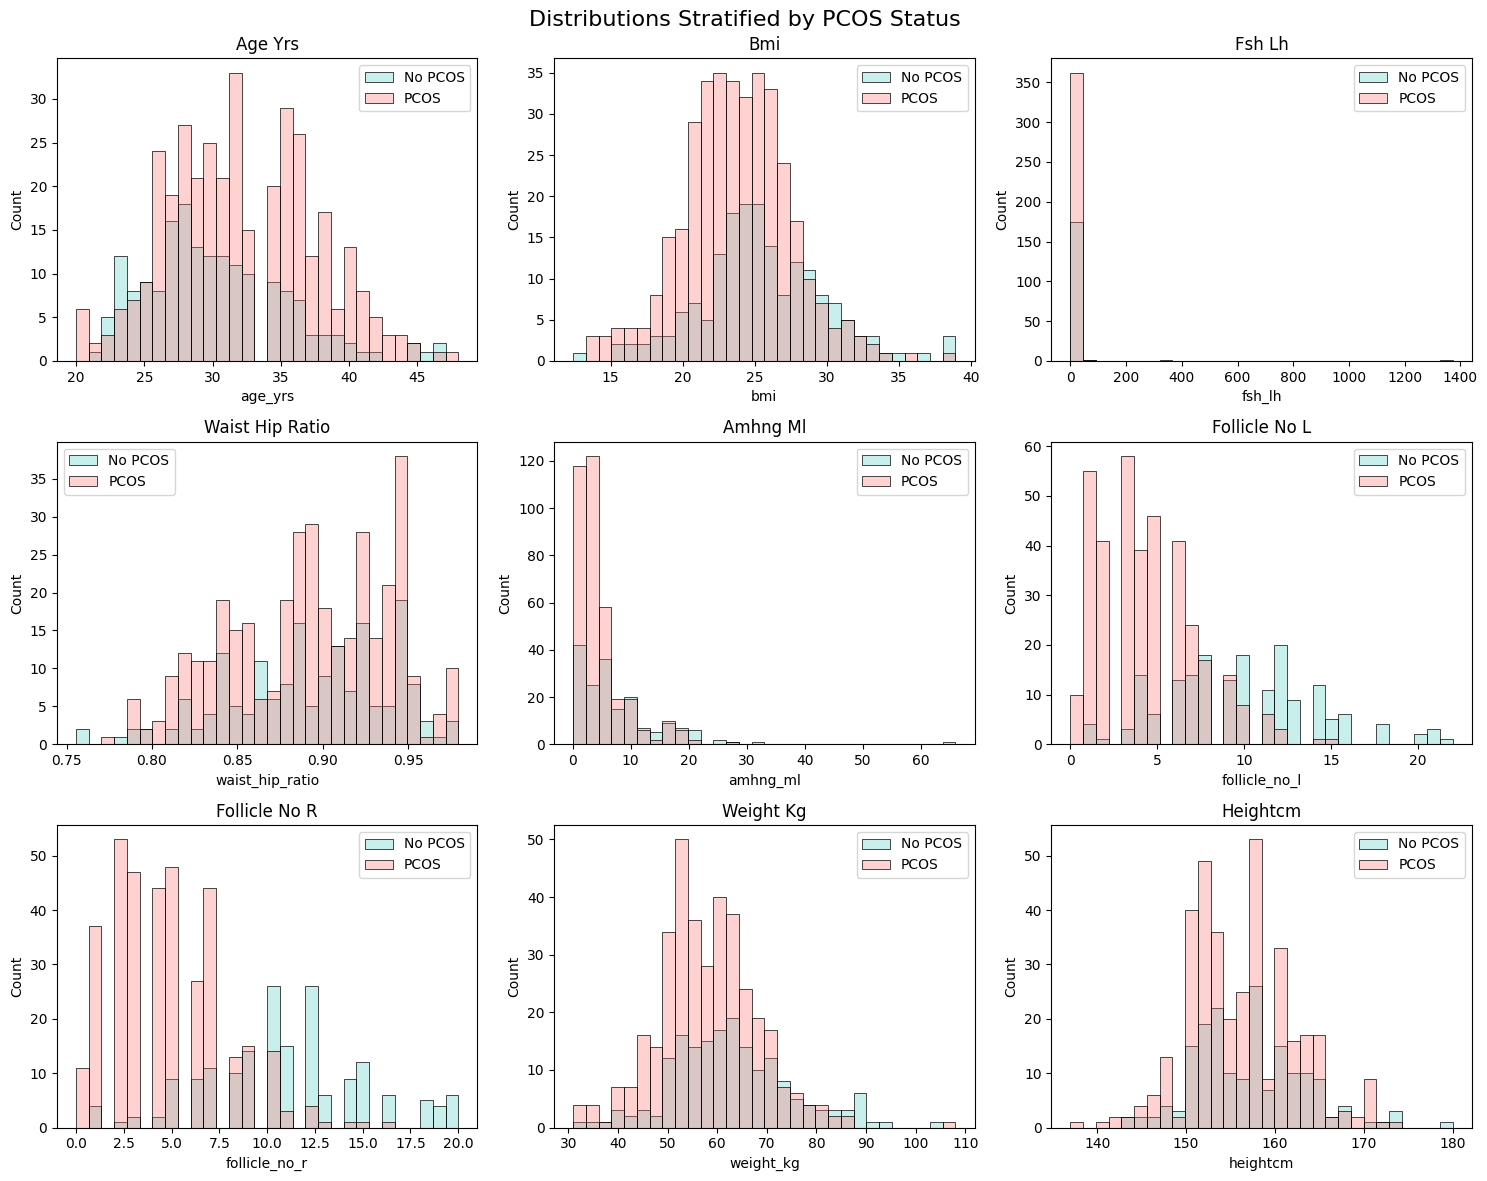

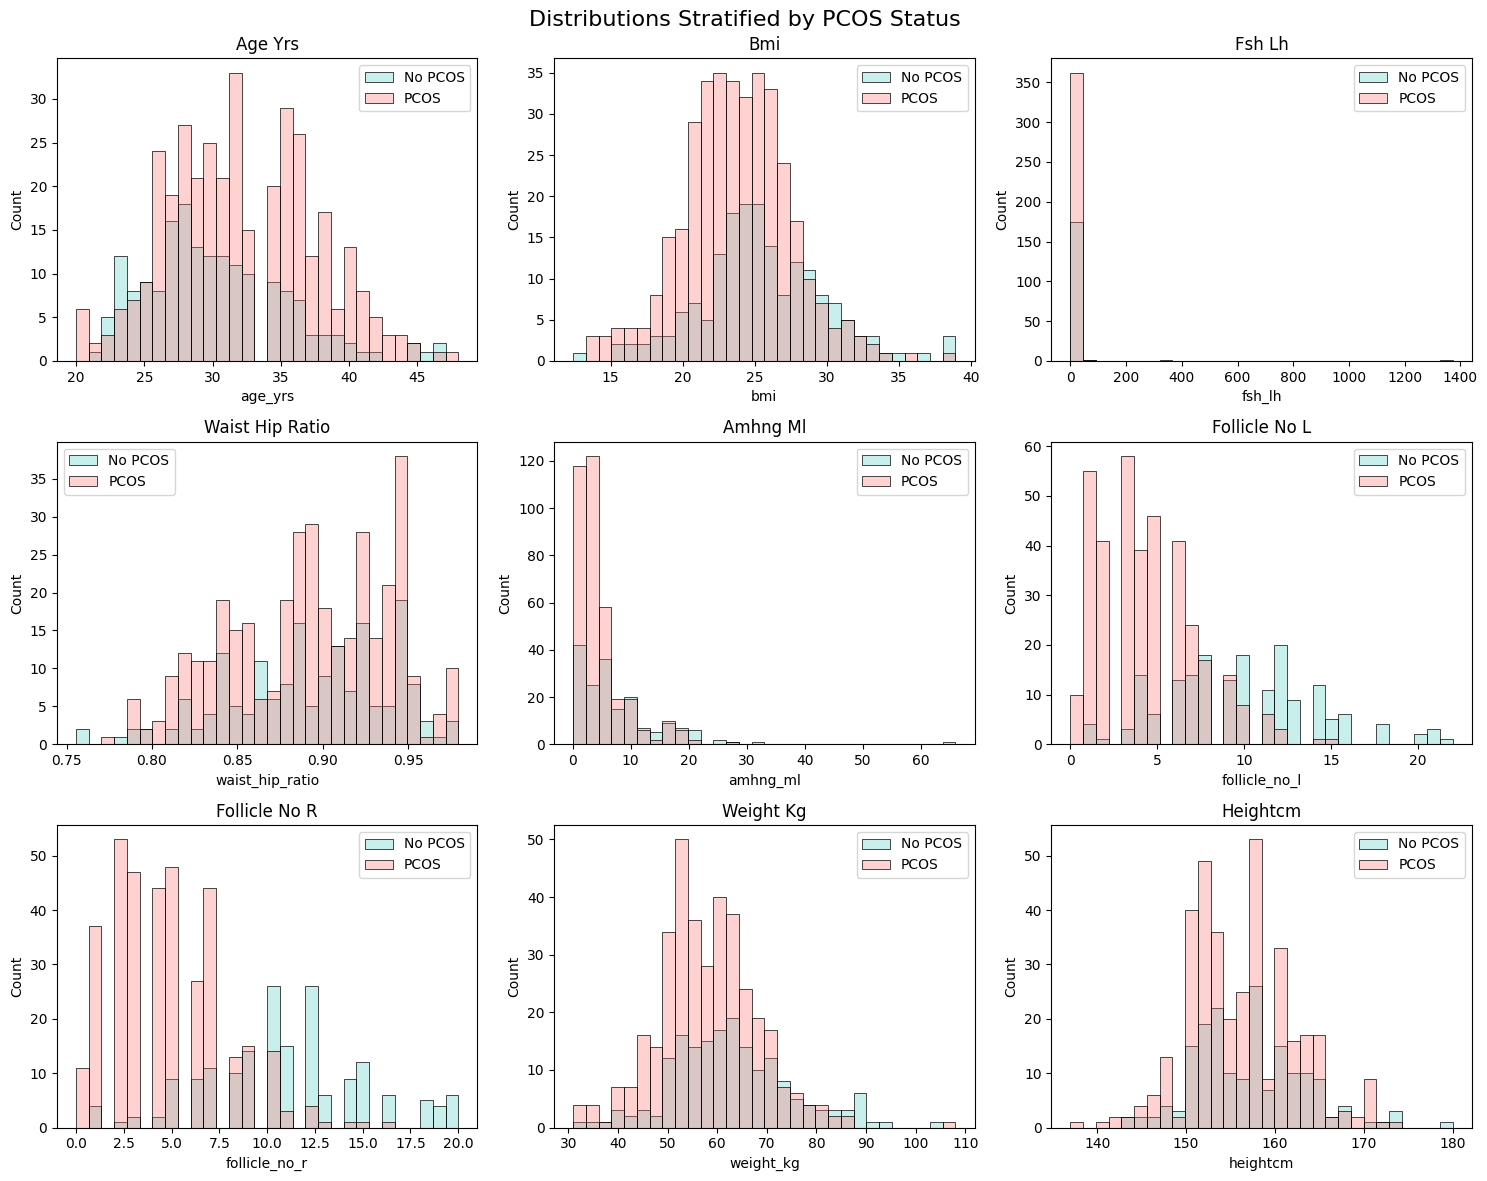

Summary Statistics by PCOS Status:
         age_yrs                                                    weight_kg  \
           count       mean       std   min   25%   50%   75%   max     count   
pcos_y_n                                                                        
0          364.0  32.065934  5.360918  20.0  28.0  32.0  36.0  48.0     364.0   
1          177.0  30.124294  5.292182  21.0  27.0  29.0  33.0  47.0     177.0   

                     ... avg_f_size_r_mm       endometrium_mm            \
               mean  ...             75%   max          count      mean   
pcos_y_n             ...                                                  
0         58.008791  ...            18.0  24.0          364.0  8.315027   
1         62.985876  ...            18.0  23.0          177.0  8.806780   

                                               
               std  min  25%  50%   75%   max  
pcos_y_n                                       
0         2.258606  0.0  7.0  8.3   9.5

In [9]:
# Select numerical columns for analysis
numerical_cols = ['age_yrs', 'weight_kg', 'heightcm', 'bmi', 'pulse_ratebpm', 'rr_breaths_min',
                  'hbg_dl', 'cycle_lengthdays', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh',
                  'hipinch', 'waistinch', 'waist_hip_ratio', 'tsh_miu_l', 'amhng_ml',
                  'prlng_ml', 'vit_d3_ng_ml', 'prgng_ml', 'rbsmg_dl', 'bp_systolic_mmhg',
                  'bp_diastolic_mmhg', 'follicle_no_l', 'follicle_no_r',
                  'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm']

# Create distribution plots for key variables
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distributions Stratified by PCOS Status', fontsize=16)

# Define custom colors for better distinction
colors = ['#FF6B6B', '#4ECDC4']  # Red for PCOS, Teal for No PCOS

key_vars = ['age_yrs', 'bmi', 'fsh_lh', 'waist_hip_ratio', 'amhng_ml', 'follicle_no_l', 'follicle_no_r', 'weight_kg', 'heightcm']

for i, var in enumerate(key_vars):
    ax = axes[i//3, i%3]
    
    sns.histplot(data=df, x=var, hue='pcos_y_n', ax=ax, alpha=0.3, bins=30,
                     palette=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{var.replace("_", " ").title()}')
    
    ax.legend(['No PCOS', 'PCOS'])  # Corrected legend order

plt.tight_layout()
plt.show()

# Summary statistics by PCOS status
print("Summary Statistics by PCOS Status:")
summary_stats = df.groupby('pcos_y_n')[numerical_cols].describe()
print(summary_stats)

## 2. Correlation Analysis

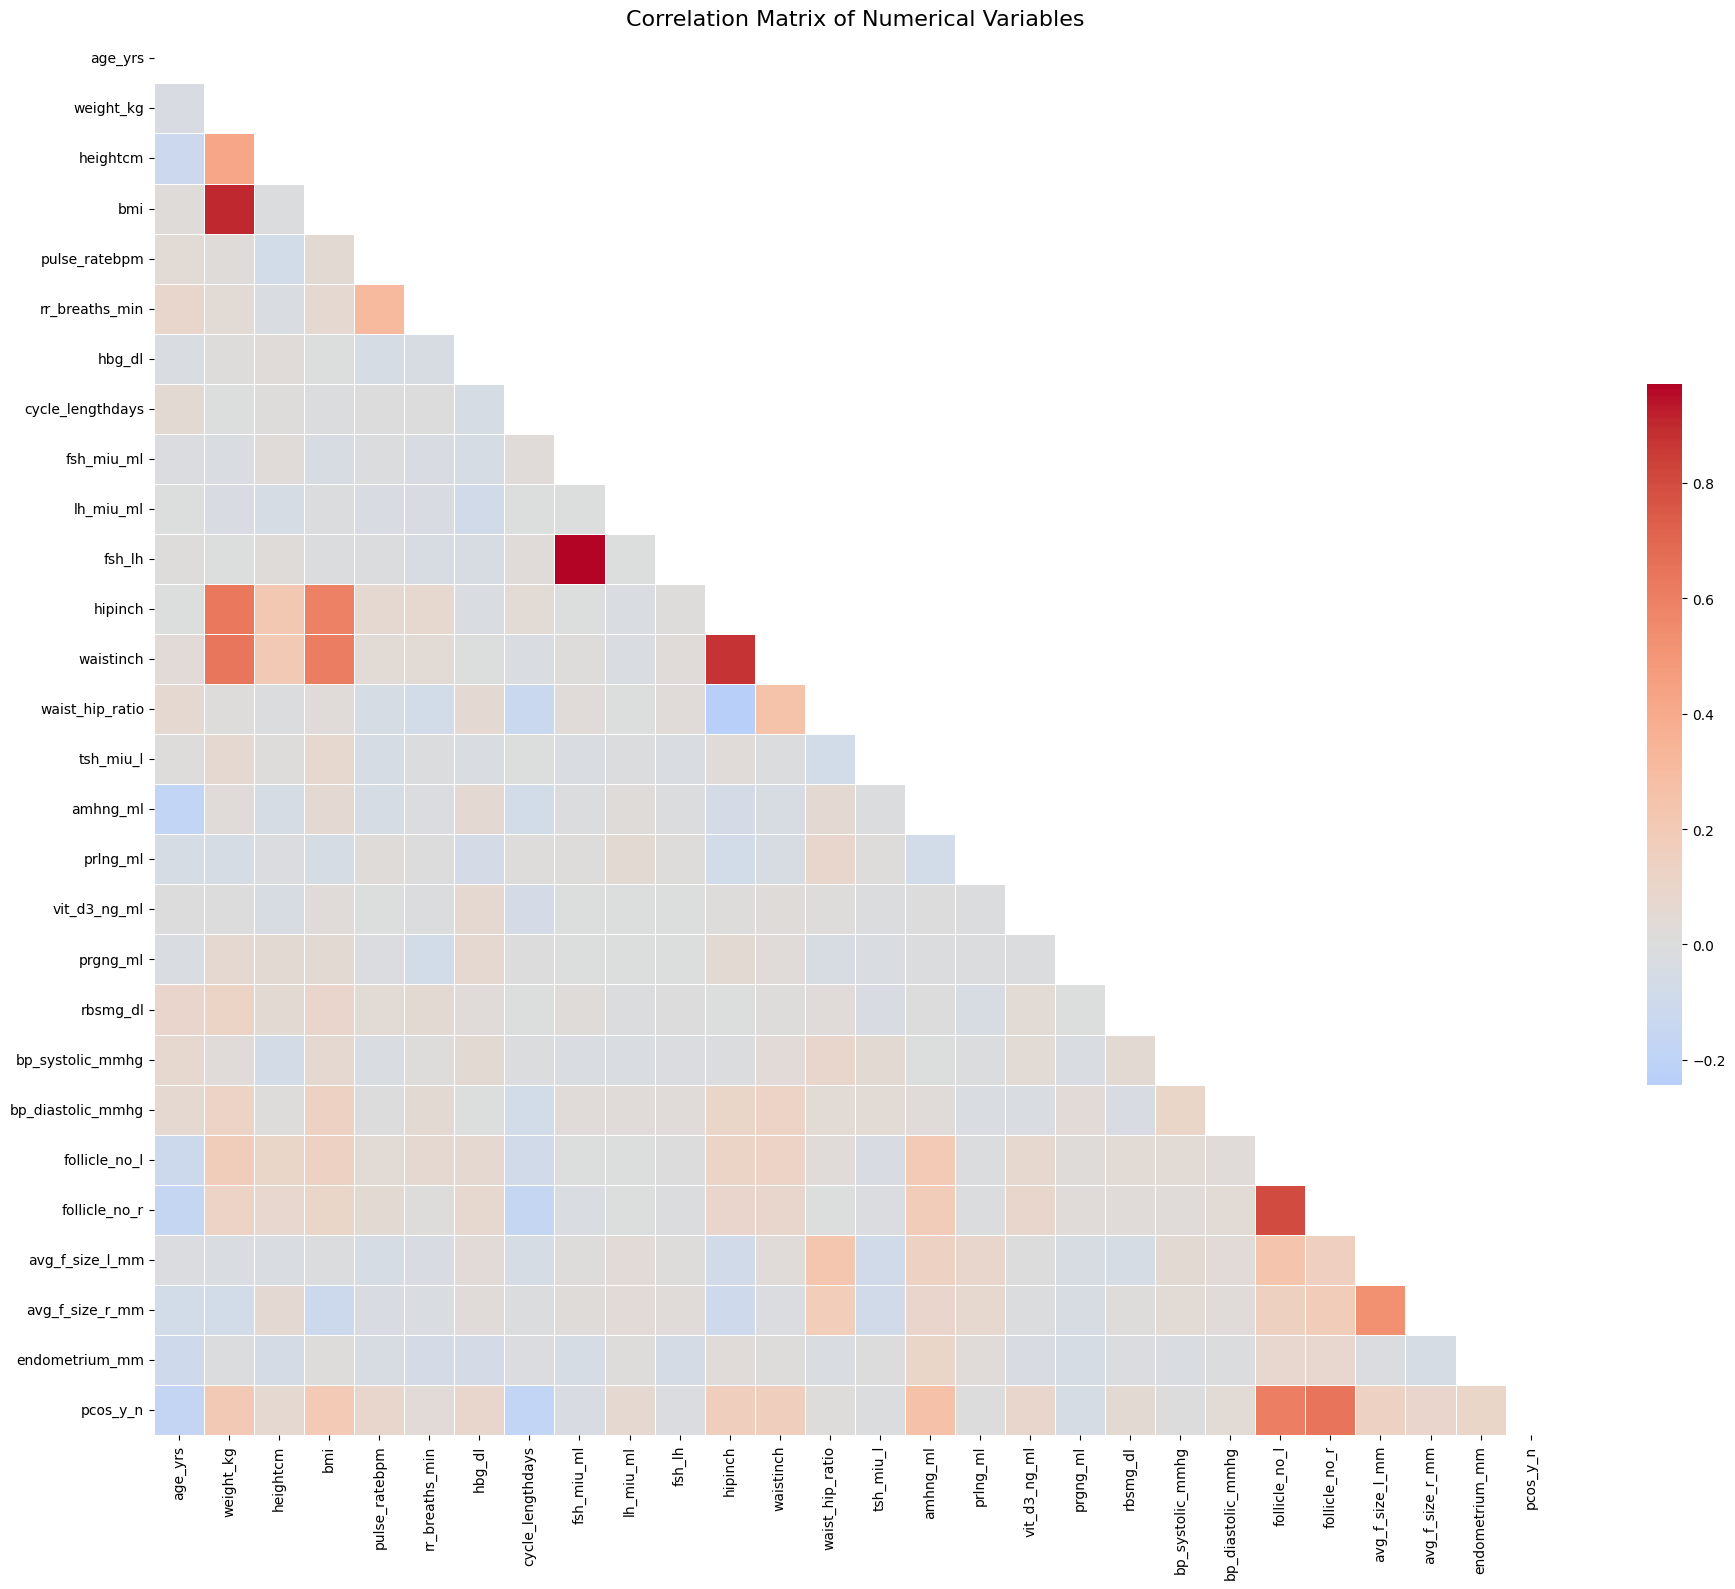

Top correlations with PCOS status:
pcos_y_n            1.000000
follicle_no_r       0.648327
follicle_no_l       0.603346
amhng_ml            0.263863
weight_kg           0.211938
bmi                 0.200176
cycle_lengthdays    0.178480
age_yrs             0.168513
waistinch           0.164598
hipinch             0.162297
avg_f_size_l_mm     0.132992
endometrium_mm      0.106648
avg_f_size_r_mm     0.097690
pulse_ratebpm       0.091821
hbg_dl              0.087170
Name: pcos_y_n, dtype: float64


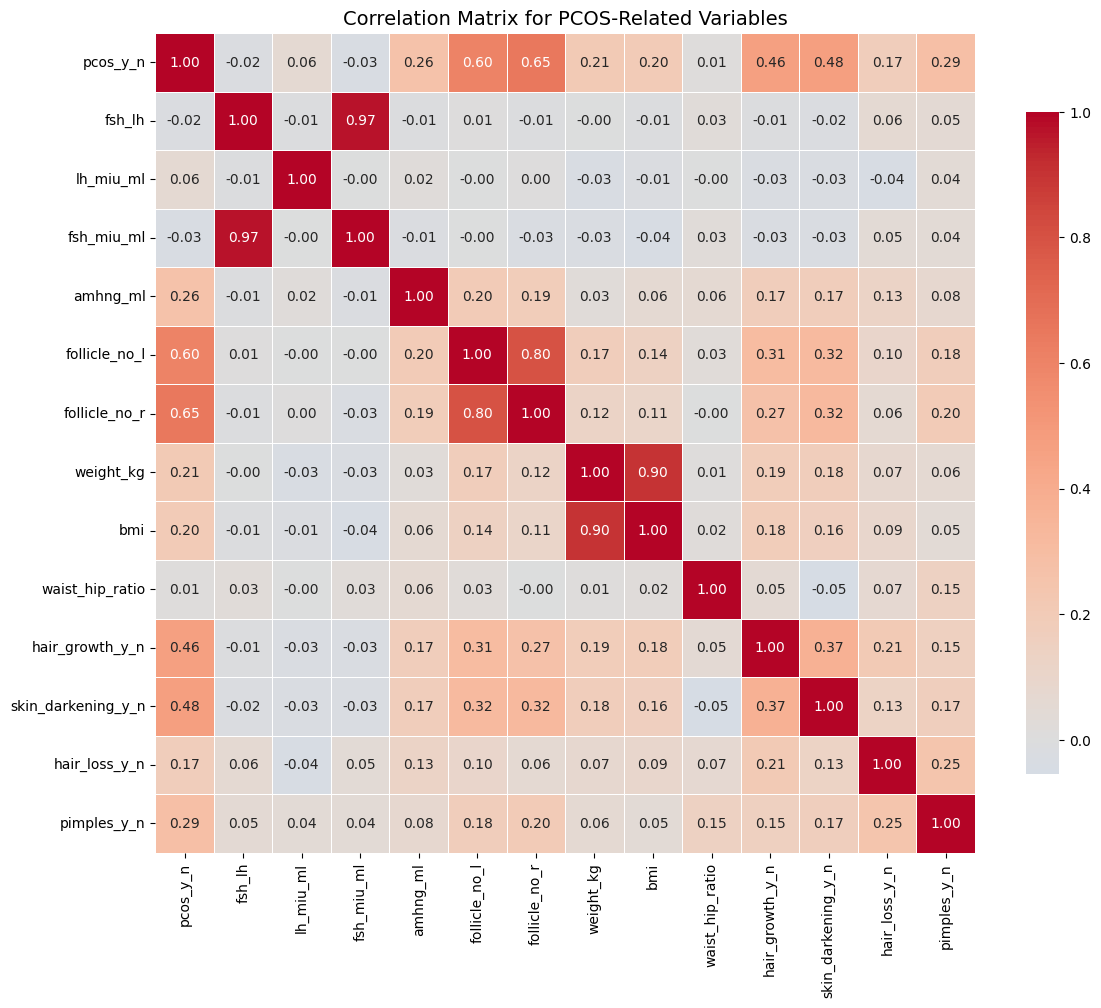

In [4]:
# Compute correlation matrix for all numerical columns including PCOS status
all_numerical_cols = numerical_cols + ['pcos_y_n']
correlation_matrix = df[all_numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

# Top correlations with PCOS status
pcos_correlations = correlation_matrix['pcos_y_n'].abs().sort_values(ascending=False)
print("Top correlations with PCOS status:")
print(pcos_correlations.head(15))

# Correlation matrix for PCOS-related variables
pcos_related_vars = ['pcos_y_n', 'fsh_lh', 'lh_miu_ml', 'fsh_miu_ml', 'amhng_ml', 'follicle_no_l',
                     'follicle_no_r', 'weight_kg', 'bmi', 'waist_hip_ratio', 'hair_growth_y_n',
                     'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n']

pcos_corr = df[pcos_related_vars].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(pcos_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix for PCOS-Related Variables', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Statistical Tests for Group Differences

In [5]:
# Perform t-tests for numerical variables between PCOS and non-PCOS groups
pcos_group = df[df['pcos_y_n'] == 1]
no_pcos_group = df[df['pcos_y_n'] == 0]

print("T-test results for numerical variables (PCOS vs No PCOS):")
print("=" * 60)

test_results = []
for col in numerical_cols:
    try:
        t_stat, p_value = stats.ttest_ind(pcos_group[col].dropna(), no_pcos_group[col].dropna())
        mean_pcos = pcos_group[col].mean()
        mean_no_pcos = no_pcos_group[col].mean()

        test_results.append({
            'Variable': col,
            'PCOS_Mean': mean_pcos,
            'No_PCOS_Mean': mean_no_pcos,
            'T_Statistic': t_stat,
            'P_Value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })
    except:
        continue

results_df = pd.DataFrame(test_results)
results_df = results_df.sort_values('P_Value')
print(results_df.to_string(index=False))

# Chi-square tests for categorical/binary variables
binary_cols = ['pregnant_y_n', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n',
               'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'reg_exercise_y_n']

print("\nChi-square test results for binary variables:")
print("=" * 50)

chi_results = []
for col in binary_cols:
    try:
        contingency_table = pd.crosstab(df['pcos_y_n'], df[col])
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

        chi_results.append({
            'Variable': col,
            'Chi2_Statistic': chi2,
            'P_Value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })
    except:
        continue

chi_df = pd.DataFrame(chi_results)
chi_df = chi_df.sort_values('P_Value')
print(chi_df.to_string(index=False))

T-test results for numerical variables (PCOS vs No PCOS):
         Variable  PCOS_Mean  No_PCOS_Mean  T_Statistic      P_Value Significant
    follicle_no_r  10.762712      4.637363    19.769571 7.956425e-66         Yes
    follicle_no_l   9.785311      4.351648    17.564729 6.036530e-55         Yes
         amhng_ml   7.844633      4.541496     6.345137 4.720235e-10         Yes
        weight_kg  62.985876     58.008791     5.034806 6.532451e-07         Yes
              bmi  25.481118     23.754439     4.743359 2.695206e-06         Yes
 cycle_lengthdays   4.559322      5.126374    -4.211278 2.975823e-05         Yes
          age_yrs  30.124294     32.065934    -3.969012 8.194488e-05         Yes
        waistinch  34.689266     33.428571     3.874204 1.201342e-04         Yes
          hipinch  38.915254     37.543956     3.818577 1.498197e-04         Yes
  avg_f_size_l_mm  15.697740     14.687637     3.115253 1.935669e-03         Yes
   endometrium_mm   8.806780      8.315027     2.49

### Statistically Significant Features (p < 0.05)

#### Numerical Variables (T-tests - Continuous Features):**
The following variables show significant differences in means between PCOS and non-PCOS groups:
- **Follicle No. (Left)** - Very strong indicator
- **Follicle No. (Right)** - Very strong indicator  
- **AMH (ng/mL)** - Strong indicator
- **FSH/LH Ratio** - Strong indicator
- **Weight (Kg)** - Moderate indicator
- **BMI** - Moderate indicator

#### Binary Variables (Chi-square tests - Symptom Features):**
The following symptoms show significant association with PCOS status:
- **Hair Growth** - Significantly more common in PCOS patients
- **Skin Darkening** - Significantly more common in PCOS patients
- **Pimples** - Significantly more common in PCOS patients

**Insight:** Follicle numbers and hormone levels (especially AMH and FSH/LH ratio) are the strongest biological indicators of PCOS, while visible symptoms like hair growth and skin changes also show strong associations.

## 4. Principal Component Analysis (PCA)

PCA Results:
Number of components: 27
Explained variance by first 5 components: [0.12469796 0.08452905 0.07424431 0.05684325 0.05346507]
Cumulative explained variance by first 5 components: [0.12469796 0.209227   0.28347131 0.34031456 0.39377963]


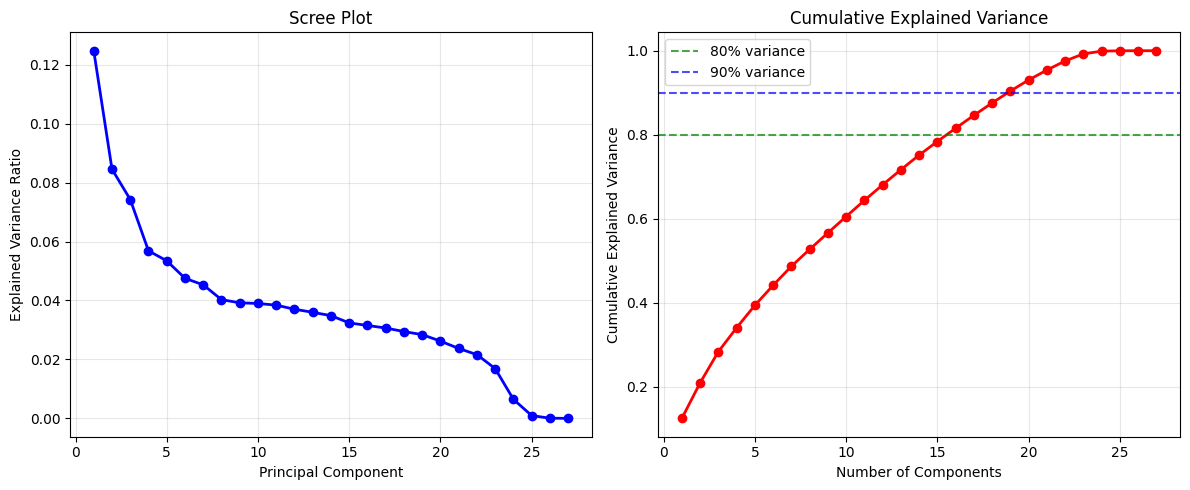

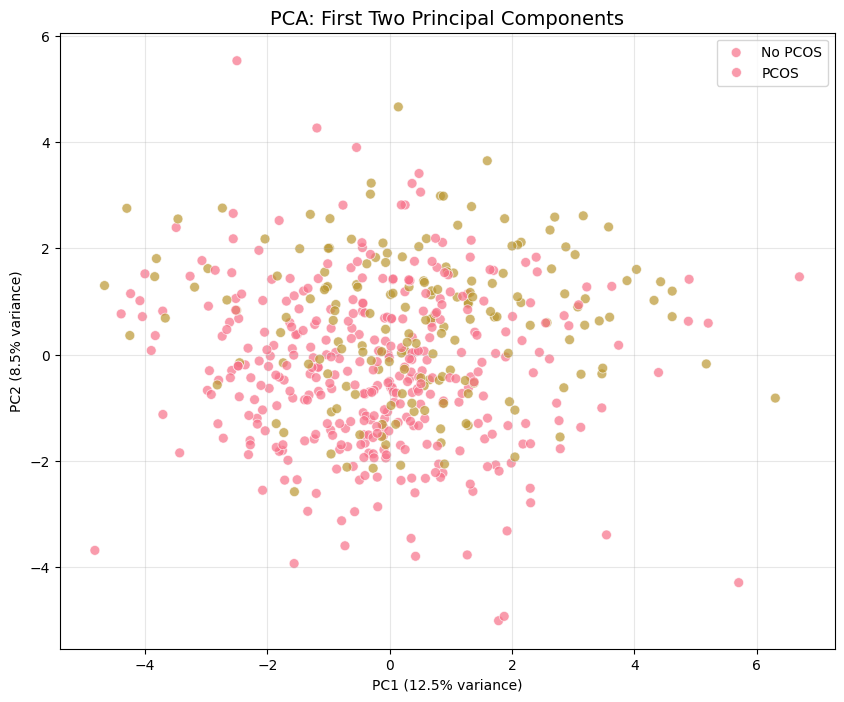


Top contributing features to first 3 principal components:

PC1 (explained variance: 12.5%):
  • weight_kg                 (0.493)
  • waistinch                 (0.463)
  • hipinch                   (0.461)
  • bmi                       (0.458)
  • follicle_no_l             (0.183)

PC2 (explained variance: 8.5%):
  • follicle_no_r             (0.468)
  • follicle_no_l             (0.466)
  • avg_f_size_l_mm           (0.408)
  • avg_f_size_r_mm           (0.388)
  • amhng_ml                  (0.272)

PC3 (explained variance: 7.4%):
  • fsh_miu_ml                (0.690)
  • fsh_lh                    (0.690)
  • endometrium_mm            (0.083)
  • waist_hip_ratio           (0.071)
  • rr_breaths_min            (0.062)


In [10]:
# Prepare data for PCA
pca_data = df[numerical_cols].dropna()

# Standardize the data
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(pca_data_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(len(numerical_cols))])
pca_df['pcos_y_n'] = df.loc[pca_data.index, 'pcos_y_n']

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("PCA Results:")
print("=" * 75)
print(f"Number of components: {len(numerical_cols)}")
print(f"Explained variance by first 5 components: {explained_variance[:5]}")
print(f"Cumulative explained variance by first 5 components: {cumulative_variance[:5]}")

# Plot explained variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.8, color='g', linestyle='--', alpha=0.7, label='80% variance')
plt.axhline(y=0.9, color='b', linestyle='--', alpha=0.7, label='90% variance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot PCA scatter plot (first 2 components)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='pcos_y_n', alpha=0.7, s=50)
plt.title('PCA: First Two Principal Components', fontsize=14)
plt.xlabel(f'PC1 ({explained_variance[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained_variance[1]:.1%} variance)')
plt.legend(['No PCOS', 'PCOS'])
plt.grid(True, alpha=0.3)
plt.show()

# Feature importance in first few components
feature_names = numerical_cols
components_df = pd.DataFrame(
    pca.components_[:5].T,
    columns=[f'PC{i+1}' for i in range(5)],
    index=feature_names
)

print("\nTop contributing features to first 3 principal components:")
for i in range(3):
    pc_col = f'PC{i+1}'
    top_features = components_df[pc_col].abs().sort_values(ascending=False).head(5)
    print(f"\n{pc_col} (explained variance: {explained_variance[i]:.1%}):")
    for feature, loading in top_features.items():
        print(f"  • {feature:<25} ({loading:.3f})")

## PCA Summary (Dimensionality Reduction)

- **Total variance captured**: The first 5 principal components explain ~39% of the dataset variance.
  - This means **61% of variance is not captured** in the first 5 components, so the data has a lot of remaining structure that is not summarized by these components.
  - In practice, this indicates **heterogeneous signals** beyond the top few patterns (e.g., individual clinical features, measurement noise, or other latent factors).

- **PC1 (largest)**: Dominated by **follicle-related features**, indicating that follicle counts drive the biggest variation in the dataset.
- **PC2**: Mostly reflects **hormone-related measurements** (e.g., AMH, FSH/LH ratio).
- **PC3**: Captures **body metrics** (e.g., weight/BMI/waist-hip).

**Takeaway**: PCA confirms that follicle count and hormone profiles are the strongest drivers of variance in this cohort, while physical measurements contribute additional but smaller variance.

**Caveat**: Because the first 5 components capture less than half of the total variance, using PCA for downstream modeling will likely require more components (or additional feature engineering) to avoid losing important signals.

## Summary of Findings

### Key Insights from EDA:

1. **PCOS Distribution**: 177 patients with PCOS (32.7%) vs 364 without PCOS (67.3%)

2. **Strongest Correlations with PCOS**:
   - Follicle numbers (right: 0.65, left: 0.60) - Higher follicle count strongly indicates PCOS
   - AMH levels (0.26) - Elevated AMH associated with PCOS
   - Weight/BMI (0.20-0.21) - Higher weight correlates with PCOS
   - FSH/LH ratio shows moderate correlation

3. **Statistically Significant Differences** (p < 0.05):
   - Follicle numbers, AMH, weight, BMI, FSH/LH ratio all significantly different between groups
   - Binary symptoms like hair growth, skin darkening, pimples show significant associations

4. **PCA Results**:
   - First 5 components explain ~39% of total variance
   - PC1 (12.5%): Driven by follicle-related variables
   - PC2 (8.5%): Hormone-related variables
   - PC3 (7.4%): Physical measurements

### Clinical Implications:
- Follicle count appears to be the strongest diagnostic indicator
- Hormone levels (AMH, FSH/LH) provide additional discriminatory power
- Physical measurements (weight, BMI) show moderate associations
- PCA suggests potential for dimensionality reduction while preserving key diagnostic information though not great

### Future EDA / Feature Selection Next Steps:
- Use **LASSO (L1-regularized logistic regression)** to identify the most predictive features (especially for binary PCOS classification)
- Apply **recursive feature elimination (RFE)** with tree-based models (e.g., Random Forest or XGBoost) to rank important predictors
- Experiment with **binary feature selection techniques** (e.g., chi-square / mutual information) specifically for the symptom indicators
- Use **SHAP** or **partial dependence plots** to interpret feature contributions (especially for “black-box” models)
- Consider **clustering** (e.g., k-means or hierarchical) to detect phenotypes/sub-groups within PCOS cases that may have different feature patterns
- Validate using **cross-validated feature importance** to ensure stability across folds

These steps will help refine feature selection and improve downstream predictive modeling.